In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
import os
import shutil


In [ ]:
training_folder_name="/content/drive/MyDrive/jaundiced_normal"

In [ ]:
img_size=(128,128)

In [ ]:
classes=sorted(os.listdir(training_folder_name))

print(classes)

['Jaundiced Eyes', 'Normal Eyes', 'Resized_Images', 'infected eyes']


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms # for
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
from PIL import Image

# function to resize image
def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image

<ipython-input-31-c2602351e5ee>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette="viridis")


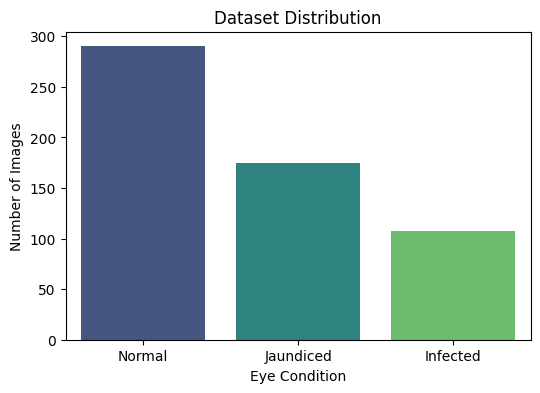

In [ ]:
#bar chart
import matplotlib.pyplot as plt
import seaborn as sns

# Labels and counts
labels = ["Normal", "Jaundiced", "Infected"]
counts = [290, 175, 107]

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=counts, palette="viridis")
plt.xlabel("Eye Condition")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()


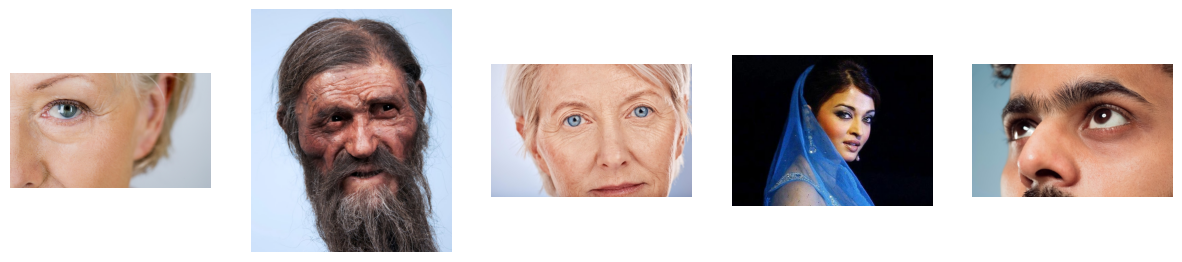

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

# Load some sample images
# image_paths = glob("/content/drive/MyDrive/jaundiced_normal")[:5]  # Change path as per your dataset
# The previous line only loaded the directories in the path.
# Glob the image files within the subdirectories.
image_paths = glob("/content/drive/MyDrive/jaundiced_normal/*/*.jpg")[:5] # Assuming images are JPG format

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, img_path in enumerate(image_paths):
    img = cv2.imread(img_path)
    # Check if image is loaded correctly
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")
    else:
        print(f"Failed to load image: {img_path}")

plt.show()

In [ ]:
import pandas as pd
from PIL import Image
from glob import glob

# Get image dimensions
img_sizes = []

# Updated glob pattern to include images within subdirectories
for img_path in glob("/content/drive/MyDrive/jaundiced_normal/*/*.jpg"): # Assuming images are JPG format
    try:
        img = Image.open(img_path)
        img_sizes.append(img.size)  # (width, height)
    except IOError:
        print(f"Failed to open image: {img_path}")  # Handle potential image opening errors

# Convert to DataFrame
df = pd.DataFrame(img_sizes, columns=["Width", "Height"])
print(df.describe())


             Width       Height
count   426.000000   426.000000
mean   1140.589202   885.617371
std     871.756082   716.102912
min     168.000000   157.000000
25%     626.000000   423.000000
50%    1000.000000   720.000000
75%    1300.000000  1080.000000
max    6880.000000  5456.000000


In [ ]:
import glob
for img_path in glob.glob("/content/drive/MyDrive/jaundiced_normal/*"):
    pass # Add your code here.  The glob function needs a wildcard to work properly.

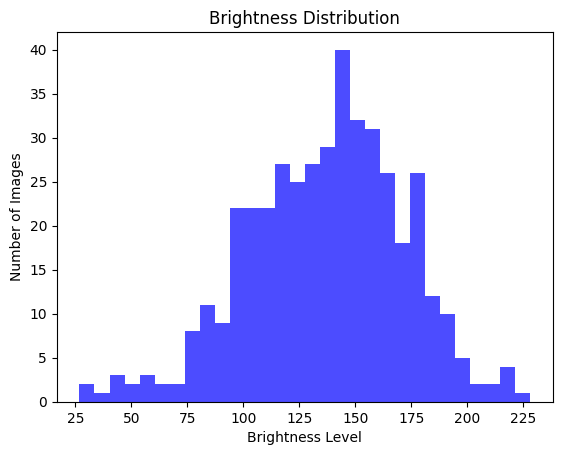

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

brightness = []

# Update glob pattern to include image files
# Assuming images are JPG format
for img_path in glob("/content/drive/MyDrive/jaundiced_normal/*/*.jpg"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Check if image is loaded correctly
    if img is not None:
        brightness.append(np.mean(img))
    else:
        print(f"Failed to load image: {img_path}")

plt.hist(brightness, bins=30, color="blue", alpha=0.7)
plt.xlabel("Brightness Level")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution")
plt.show()

In [ ]:
import hashlib
from glob import glob

hashes = set()
duplicates = 0

# Update glob pattern to include image files within subdirectories
for img_path in glob("/content/drive/MyDrive/jaundiced_normal/*/*.jpg"):  # Assuming images are JPG format
    with open(img_path, "rb") as f:
        img_hash = hashlib.md5(f.read()).hexdigest()

    if img_hash in hashes:
        duplicates += 1
    else:
        hashes.add(img_hash)

print(f"Total Duplicates Found: {duplicates}")

Total Duplicates Found: 34


In [ ]:
training_folder_name = '/content/drive/MyDrive/jaundiced_normal'

# New location for the resized images
train_folder = '/content/drive/MyDrive/jaundiced_normal/Resized_Images'


# Create resized copies of all of the source images
size = (128,128)

# Create the output folder if it doesn't already exist
if os.path.exists(train_folder):
    shutil.rmtree(train_folder)

# Loop through each subfolder in the input folder
print('Transforming images...')
for root, folders, files in os.walk(training_folder_name):
    for sub_folder in folders:
        print('processing folder ' + sub_folder)
        # Create a matching subfolder in the output dir
        saveFolder = os.path.join(train_folder,sub_folder)
        if not os.path.exists(saveFolder):
            os.makedirs(saveFolder)
        # Loop through the files in the subfolder
        file_names = os.listdir(os.path.join(root,sub_folder))
        for file_name in file_names:
            # Check if the file is an actual file and not a directory (like .ipynb_checkpoints)
            file_path = os.path.join(root, sub_folder, file_name)
            if os.path.isfile(file_path): #this condition helps to only run the script on image files rather than on all objects.
                #print("reading " + file_path)
                image = Image.open(file_path)
                # Create a resized version and save it
                resized_image = resize_image(image, size)
                saveAs = os.path.join(saveFolder, file_name)
                #print("writing " + saveAs)
                resized_image.save(saveAs)

print('Done.')

Transforming images...
processing folder Normal Eyes
processing folder infected eyes
processing folder Jaundiced Eyes
Done.


In [ ]:
def load_dataset(data_path):
    import torch
    import torchvision
    import torchvision.transforms as transforms
    # Load all the images
    transformation = transforms.Compose([
        # Randomly augment the image data
            # Random horizontal flip
        transforms.RandomHorizontalFlip(0.5),
            # Random vertical flip
        transforms.RandomVerticalFlip(0.5),
        # transform to tensors
        transforms.ToTensor(),
        # Normalize the pixel values (in R, G, and B channels)
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Load all of the images, transforming them
    full_dataset = torchvision.datasets.ImageFolder(
        root=data_path,
        transform=transformation
    )


    # Split into training (70% and testing (30%) datasets)
    train_size = int(0.7 * len(full_dataset))
    test_size = len(full_dataset) - train_size

    # use torch.utils.data.random_split for training/test split
    train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

    # define a loader for the training data we can iterate through in 50-image batches
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=50,
        num_workers=0,
        shuffle=False
    )

    # define a loader for the testing data we can iterate through in 50-image batches
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=1,
        num_workers=0,
        shuffle=False
    )

    return train_loader, test_loader


In [ ]:
# Recall that we have resized the images and saved them into
train_folder = '/content/drive/MyDrive/jaundiced_normal/Resized_Images'

# Get the iterative dataloaders for test and training data
train_loader, test_loader = load_dataset(train_folder)
batch_size = train_loader.batch_size
print("Data loaders ready to read", train_folder)

Data loaders ready to read /content/drive/MyDrive/jaundiced_normal/Resized_Images


In [ ]:
# Create a neural net class
class Net(nn.Module):
    # Defining the Constructor
    def __init__(self, num_classes):
        super(Net, self).__init__()

        # In the init function, we define each layer we will use in our model

        # Our images are RGB, so we have input channels = 3.
        # We will apply 3er12 filters in the first convolutional layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)


        # A second convolutional layer takes 12 input channels, and generates 24 outputs
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=24, out_channels=48, kernel_size=3, stride=1, padding=1)

        # We in the end apply max pooling with a kernel size of 2
        self.pool = nn.MaxPool2d(kernel_size=2)

        # A drop layer deletes 20% of the features to help prevent overfitting
        self.drop = nn.Dropout(p=0.2)

        # Our 128x128 image tensors will be pooled twice with a kernel size of 2. 128/2/2 is 32.
        # This means that our feature tensors are now 32 x 32, and we've generated 24 of them

        # We need to flatten these in order to feed them to a fully-connected layer
        self.fc = nn.Linear(in_features=32 * 32 * 24, out_features=num_classes)

    def forward(self, x):
        # In the forward function, pass the data through the layers we defined in the init function

        # Use a ReLU activation function after layer 1 (convolution 1 and pool)
        x = F.relu(self.pool(self.conv1(x)))

        # Use a ReLU activation function after layer 2
        x = F.relu(self.pool(self.conv2(x)))

        # Select some features to drop to prevent overfitting (only drop during training)
        x = F.dropout(self.drop(x), training=self.training)

        # Flatten
        x = x.view(-1, 32 * 32 * 24)
        # Feed to fully-connected layer to predict class
        x = self.fc(x)
        # Return class probabilities via a log_softmax function
        return torch.log_softmax(x, dim=1)


device = "cpu"
if (torch.cuda.is_available()):
    # if GPU available, use cuda (on a cpu, training will take a considerable length of time!)
    device = "cuda"

# Create an instance of the model class and allocate it to the device
model = Net(num_classes=len(classes)).to(device)

print(model)

Net(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=24576, out_features=3, bias=True)
)


In [ ]:
def train(model, device, train_loader, optimizer, epoch):
    # Set the model to training mode
    model.train()
    train_loss = 0
    print("Epoch:", epoch)
    # Process the images in batches
    for batch_idx, (data, target) in enumerate(train_loader):
        # Use the CPU or GPU as appropriate
        # Recall that GPU is optimized for the operations we are dealing with
        data, target = data.to(device), target.to(device)

        # Reset the optimizer
        optimizer.zero_grad()

        # Push the data forward through the model layers
        output = model(data)

        # Get the loss
        loss = loss_criteria(output, target)

        # Keep a running total
        train_loss += loss.item()

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Print metrics so we see some progress
        print('\tTraining batch {} Loss: {:.6f}'.format(batch_idx + 1, loss.item()))

    # return average loss for the epoch
    avg_loss = train_loss / (batch_idx+1)
    print('Training set: Average loss: {:.6f}'.format(avg_loss))
    return avg_loss

In [ ]:
def test(model, device, test_loader):
    # Switch the model to evaluation mode (so we don't backpropagate or drop)
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        batch_count = 0
        for data, target in test_loader:
            batch_count += 1
            data, target = data.to(device), target.to(device)

            # Get the predicted classes for this batch
            output = model(data)

            # Calculate the loss for this batch
            test_loss += loss_criteria(output, target).item()

            # Calculate the accuracy for this batch
            _, predicted = torch.max(output.data, 1)
            correct += torch.sum(target==predicted).item()

    # Calculate the average loss and total accuracy for this epoch
    avg_loss = test_loss / batch_count
    print('Validation set: Average loss: {:.6f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        avg_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    # return average loss for the epoch
    return avg_loss

In [ ]:
# Use an "Adam" optimizer to adjust weights
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Specify the loss criteria
class_weights = torch.ones(3)
class_weights[0] = 5.0
class_weights[1] = 3.0
class_weights[2] = 4.5

loss_criteria = nn.CrossEntropyLoss(weight=class_weights)

# Track metrics in these arrays
epoch_nums = []
training_loss = []
validation_loss = []

# Train over 10 epochs (We restrict to 10 for time issues)
epochs = 150
print('Training on', device)
for epoch in range(1, epochs + 1):
        train_loss = train(model, device, train_loader, optimizer, epoch)
        test_loss = test(model, device, test_loader)
        epoch_nums.append(epoch)
        training_loss.append(train_loss)
        validation_loss.append(test_loss)

Training on cpu
Epoch: 1
	Training batch 1 Loss: 1.097899
	Training batch 2 Loss: 1.389728
	Training batch 3 Loss: 1.194053
	Training batch 4 Loss: 0.997286
	Training batch 5 Loss: 1.081570
	Training batch 6 Loss: 1.181698
	Training batch 7 Loss: 1.016059
	Training batch 8 Loss: 1.029302
Training set: Average loss: 1.123449
Validation set: Average loss: 1.136942, Accuracy: 62/172 (36%)

Epoch: 2
	Training batch 1 Loss: 0.995560
	Training batch 2 Loss: 1.056625
	Training batch 3 Loss: 1.051491
	Training batch 4 Loss: 1.020243
	Training batch 5 Loss: 0.942834
	Training batch 6 Loss: 0.992356
	Training batch 7 Loss: 0.972760
	Training batch 8 Loss: 0.968114
Training set: Average loss: 0.999998
Validation set: Average loss: 0.939670, Accuracy: 91/172 (53%)

Epoch: 3
	Training batch 1 Loss: 0.832167
	Training batch 2 Loss: 0.922044
	Training batch 3 Loss: 0.931938
	Training batch 4 Loss: 0.798496
	Training batch 5 Loss: 0.876704
	Training batch 6 Loss: 1.093307
	Training batch 7 Loss: 0.890

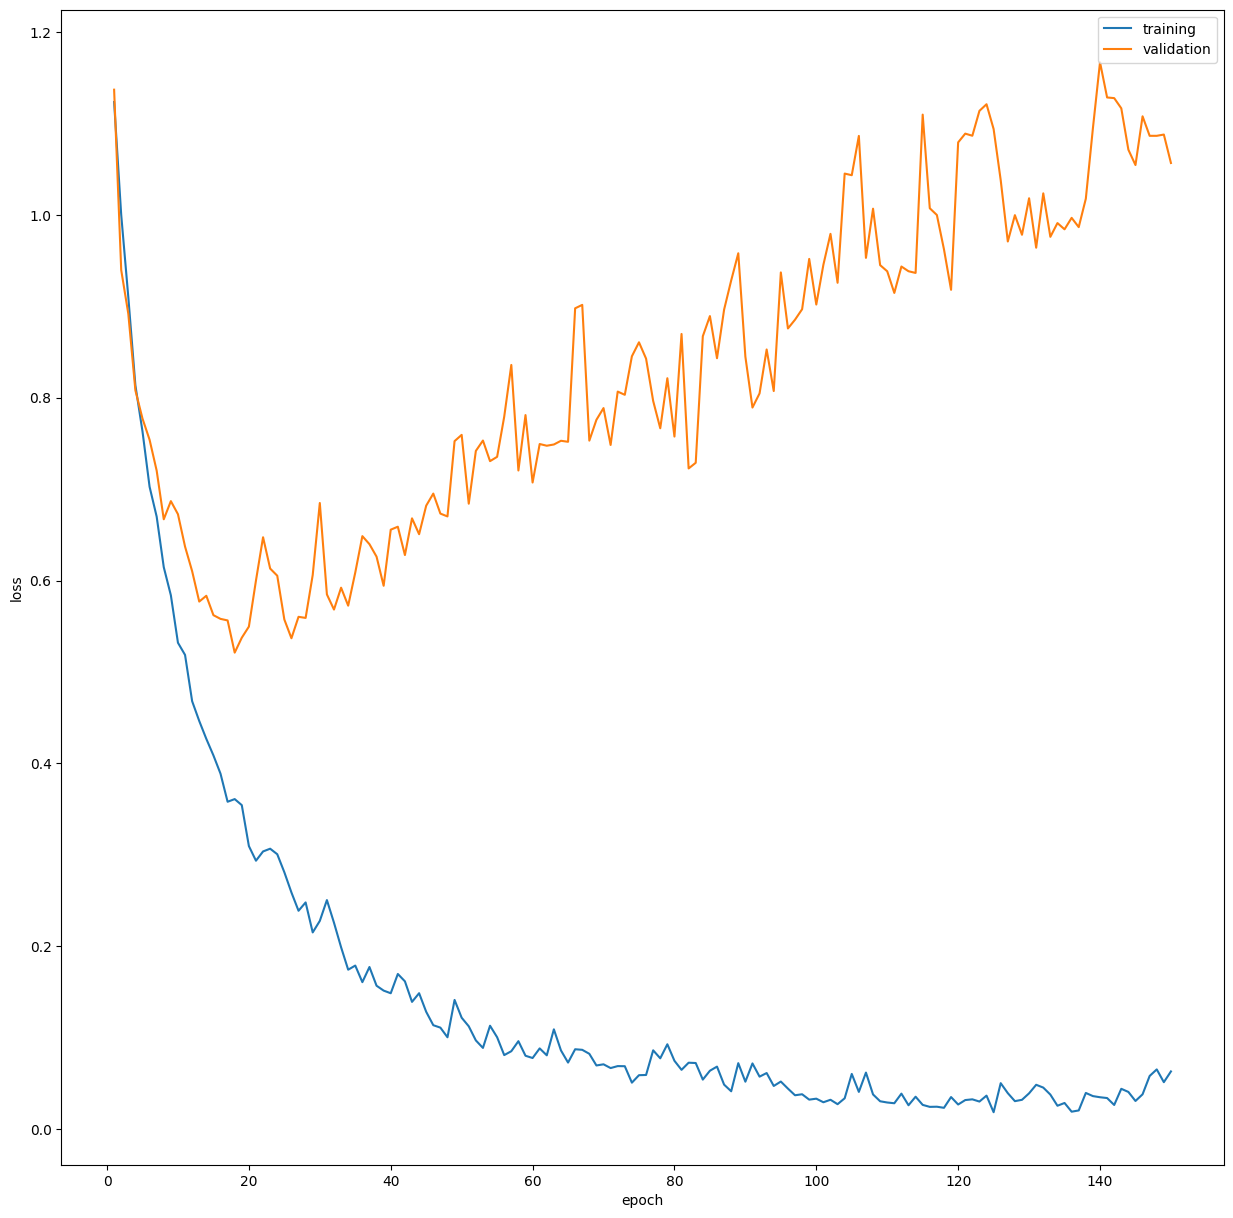

In [ ]:
plt.figure(figsize=(15,15))
plt.plot(epoch_nums, training_loss)
plt.plot(epoch_nums, validation_loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training', 'validation'], loc='upper right')
plt.show()

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

Getting predictions from test set...
F1 score (weighted-average): 0.8196
ROC Curve


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


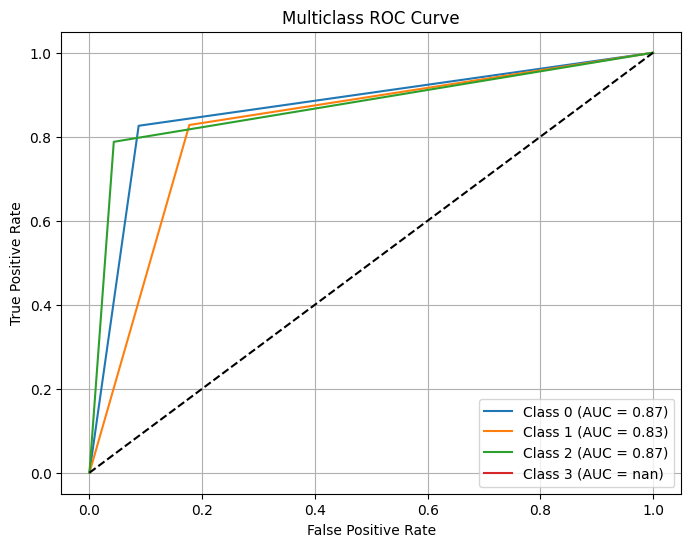

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


Multiclass AUROC: 0.6418


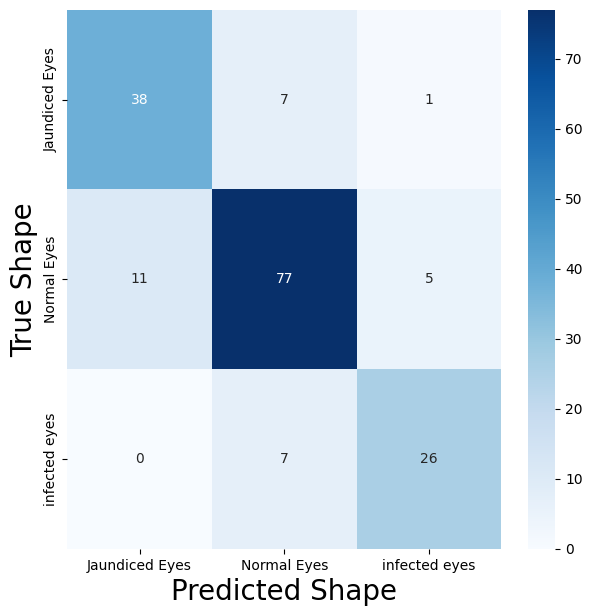

In [ ]:
import numpy as np
import pandas as pd
truelabels = []
predictions = []
model.eval()
print("Getting predictions from test set...")
for data, target in test_loader:
    for label in target.data.numpy():
        truelabels.append(label)
    for prediction in model(data).data.numpy().argmax(1):
        predictions.append(prediction)
from torchmetrics.classification import MulticlassF1Score
true_labels_tensor = torch.tensor(truelabels)
predictions_tensor = torch.tensor(predictions)
num_classes = 4
f1_macro = MulticlassF1Score(num_classes=num_classes, average='weighted')
f1_macro.update(true_labels_tensor,predictions_tensor)
print(f"F1 score (weighted-average): {f1_macro.compute():.4f}")
# Plot the confusion matrix
cm = confusion_matrix(truelabels, predictions)
tick_marks = np.arange(len(classes))

print("ROC Curve")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
from torchmetrics.classification import MulticlassAUROC


y_score_onehot = torch.nn.functional.one_hot(torch.tensor(predictions), num_classes=num_classes).float()


y_true = torch.tensor(truelabels)  # Replace with your ground truth

# Compute ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true == i, y_score_onehot[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot individual curves
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Add diagonal line
plt.plot([0, 1], [0, 1], 'k--')

# Customize plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()

metric = MulticlassAUROC(num_classes=num_classes)
metric.update(y_score_onehot, y_true)
auroc = metric.compute()
print(f"Multiclass AUROC: {auroc:.4f}")

df_cm = pd.DataFrame(cm, index = classes, columns = classes)
plt.figure(figsize = (7,7))
sns.heatmap(df_cm, annot=True, cmap=plt.cm.Blues, fmt='g')
plt.xlabel("Predicted Shape", fontsize = 20)
plt.ylabel("True Shape", fontsize = 20)
plt.show()

In [ ]:
def Predict_class():
  from PIL import Image
  inp="/content/drive/MyDrive/yellow-eyes.webp"
  def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image
  image = Image.open(inp)
  resized_image = resize_image(image, size=(128,128))
  resized_image.save(inp)
  inp = transforms.ToTensor()(Image.open(inp))
  inp1 = transforms.RandomHorizontalFlip(0.5)(inp)
  inp2 = transforms.RandomVerticalFlip(0.5)(inp1)
  inp3 = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(inp2)
  model.eval()
  with torch.no_grad():
    output = model(inp3)
    print(output.argmax())
    if output.argmax() == 0:
      print("The given Image belongs to JAUNDICE Eyes ")
    elif output.argmax() == 1:
      print("The given Image belongs NORMAL Eyes")
    elif output.argmax() == 2:
      print("The given Image belongs to INFECTED Eyes")

Predict_class()

tensor(0)
The given Image belongs to JAUNDICE Eyes 


In [ ]:
def Predict_class():
  from PIL import Image
  inp="/content/drive/MyDrive/NORMAL EYES 1.webp"
  def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image
  image = Image.open(inp)
  resized_image = resize_image(image, size=(128,128))
  resized_image.save(inp)
  inp = transforms.ToTensor()(Image.open(inp))
  inp1 = transforms.RandomHorizontalFlip(0.5)(inp)
  inp2 = transforms.RandomVerticalFlip(0.5)(inp1)
  inp3 = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(inp2)
  model.eval()
  with torch.no_grad():
    output = model(inp3)
    print(output.argmax())
    if output.argmax() == 0:
      print("The given Image belongs to JAUNDICE Eyes ")
    elif output.argmax() == 1:
      print("The given Image belongs NORMAL Eyes")
    elif output.argmax() == 2:
      print("The given Image belongs to INFECTED Eyes")

Predict_class()

tensor(1)
The given Image belongs NORMAL Eyes


In [ ]:
def Predict_class():
  from PIL import Image
  inp="/content/drive/MyDrive/INFECTED EYE 1.jpg"
  def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image
  image = Image.open(inp)
  resized_image = resize_image(image, size=(128,128))
  resized_image.save(inp)
  inp = transforms.ToTensor()(Image.open(inp))
  inp1 = transforms.RandomHorizontalFlip(0.5)(inp)
  inp2 = transforms.RandomVerticalFlip(0.5)(inp1)
  inp3 = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(inp2)
  model.eval()
  with torch.no_grad():
    output = model(inp3)
    print(output.argmax())
    if output.argmax() == 0:
      print("The given Image belongs to JAUNDICE Eyes ")
    elif output.argmax() == 1:
      print("The given Image belongs NORMAL Eyes")
    elif output.argmax() == 2:
      print("The given Image belongs to INFECTED Eyes")

Predict_class()

tensor(2)
The given Image belongs to INFECTED Eyes


In [ ]:
def Predict_class():
  from PIL import Image
  inp="/content/drive/MyDrive/YELLOW 3.jpg"
  def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image
  image = Image.open(inp)
  resized_image = resize_image(image, size=(128,128))
  resized_image.save(inp)
  inp = transforms.ToTensor()(Image.open(inp))
  inp1 = transforms.RandomHorizontalFlip(0.5)(inp)
  inp2 = transforms.RandomVerticalFlip(0.5)(inp1)
  inp3 = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(inp2)
  model.eval()
  with torch.no_grad():
    output = model(inp3)
    print(output.argmax())
    if output.argmax() == 0:
      print("The given Image belongs to JAUNDICE Eyes ")
    elif output.argmax() == 1:
      print("The given Image belongs NORMAL Eyes")
    elif output.argmax() == 2:
      print("The given Image belongs to INFECTED Eyes")
Predict_class()

tensor(0)
The given Image belongs to JAUNDICE Eyes 


In [ ]:
def Predict_class():
  from PIL import Image
  inp="/content/drive/MyDrive/sruthi eyes.jpg"
  def resize_image(src_image, size=(128,128), bg_color="white"):
    from PIL import Image, ImageOps

    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.LANCZOS)

    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)

    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))

    # return the resized image
    return new_image
  image = Image.open(inp)
  resized_image = resize_image(image, size=(128,128))
  resized_image.save(inp)
  inp = transforms.ToTensor()(Image.open(inp))
  inp1 = transforms.RandomHorizontalFlip(0.5)(inp)
  inp2 = transforms.RandomVerticalFlip(0.5)(inp1)
  inp3 = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(inp2)
  model.eval()
  with torch.no_grad():
    output = model(inp3)
    print(output.argmax())
    if output.argmax() == 0:
      print("The given Image belongs to JAUNDICE Eyes ")
    elif output.argmax() == 1:
      print("The given Image belongs NORMAL Eyes")
    elif output.argmax() == 2:
      print("The given Image belongs to INFECTED Eyes")
Predict_class()

tensor(0)
The given Image belongs to JAUNDICE Eyes 
